# STEP 1 IMPORTING REQUIRED LIBRARIES

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

The customer segmentation analysis successfully processes the Online Retail dataset through data cleaning, RFM analysis, feature standardisation, and K-Means clustering. Customers are grouped into distinct segments based on their Recency, Frequency, and Monetary (RFM) characteristics. The visualisations and cluster profiles help identify differences in customer purchasing behaviour and provide useful insights for targeted marketing strategies, customer retention, personalised promotions, and improving customer value.

# STEP 2: LOAD THE DATASET

In [20]:
import pandas as pd
df = pd.read_csv("Online_Retail.csv", encoding="latin1")
display(df.head())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# STEP 3: INSPECT DATASET STRUCTURE

In [21]:
print("Dataset Shape:",df.shape)
print("\nColumn Names:")

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (541909, 8)

Column Names:

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows:
5268


# STEP 4: CLEAN THE DATA

In [24]:
# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["UnitPrice"] > 0]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(subset=["InvoiceDate"])

# Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

print("Shape after cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Shape after cleaning: (392692, 9)

Missing Values After Cleaning:
InvoiceNo             0
StockCode             0
Description           0
Quantity              0
InvoiceDate           0
UnitPrice             0
CustomerID            0
Country               0
TotalPurchaseValue    0
dtype: int64


# STEP 5: CALCULATE TOTAL PURCHASE VALUE

In [23]:
df["TotalPurchaseValue"] = df["Quantity"] * df["UnitPrice"]

print("Average Purchase Value:",
      round(df["TotalPurchaseValue"].mean(), 2))

print("Total Sales:",
      round(df["TotalPurchaseValue"].sum(), 2))

print("Total Transactions:",
      df["InvoiceNo"].nunique())

print("Total Customers:",
      df["CustomerID"].nunique())

Average Purchase Value: 22.63
Total Sales: 8887208.89
Total Transactions: 18532
Total Customers: 4338


# STEP 6:CREATE RFM ANALYSIS

In [6]:
# Analysis date = one day after the last transaction
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Calculate Recency, Frequency and Monetary Value
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPurchaseValue": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


# STEP 7:DESCRIPTIVE STATISTICS

In [7]:
print("RFM Descriptive Statistics:")
display(rfm.describe())

print("Average Recency:",
      round(rfm["Recency"].mean(), 2))

print("Average Purchase Frequency:",
      round(rfm["Frequency"].mean(), 2))

print("Average Customer Monetary Value (CLV Proxy):",
      round(rfm["Monetary"].mean(), 2))

RFM Descriptive Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


Average Recency: 92.54
Average Purchase Frequency: 4.27
Average Customer Monetary Value (CLV Proxy): 2048.69


# STEP 8:HANDLE EXTREME OUTLIERS

In [8]:
rfm_clean = rfm.copy()

for column in ["Recency", "Frequency", "Monetary"]:
    lower = rfm_clean[column].quantile(0.01)
    upper = rfm_clean[column].quantile(0.99)

    rfm_clean = rfm_clean[
        (rfm_clean[column] >= lower) &
        (rfm_clean[column] <= upper)
    ]

print("RFM data after outlier treatment:")
print(rfm_clean.shape)

RFM data after outlier treatment:
(4169, 3)


# STEP 9: SELECT FEATURES FOR CLUSTERING

In [9]:
features = ["Recency", "Frequency", "Monetary"]

X = rfm_clean[features]

display(X.head())

,Recency,Frequency,Monetary
CustomerID,,,
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,2506.04


# STEP 10: STANDARDISE THE DATA

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data standardisation completed.")

Data standardisation completed.


# STEP 11:  ELBOW METHOD TO FIND OPTIMAL K


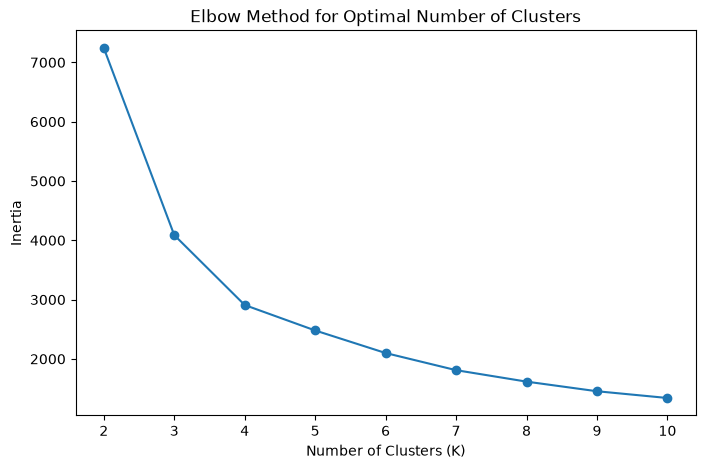

In [11]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)

plt.show()

# STEP 12: APPLY K.MEANS CLUSTERING

In [12]:
# Select K based on the Elbow Method
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm_clean["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")

print("\nNumber of Customers in Each Cluster:")
print(rfm_clean["Cluster"].value_counts().sort_index())

K-Means clustering completed.

Number of Customers in Each Cluster:
Cluster
0    2150
1     220
2     825
3     974
Name: count, dtype: int64


# STEP 13: PROFILE EACH CLUSTER

In [13]:
cluster_profile = rfm_clean.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Monetary=("Monetary", "mean")
).round(2)

print("Cluster Profile:")
display(cluster_profile)

Cluster Profile:


,Customers,Average_Recency,Average_Frequency,Average_Monetary
Cluster,,,,
0,2150,50.99,2.25,663.45
1,220,19.64,14.97,6808.87
2,825,30.50,6.86,2581.46
3,974,246.11,1.52,448.09


# STEP 14:VISUALISE CLUSTERS - RECENCY VS FREQUENCY


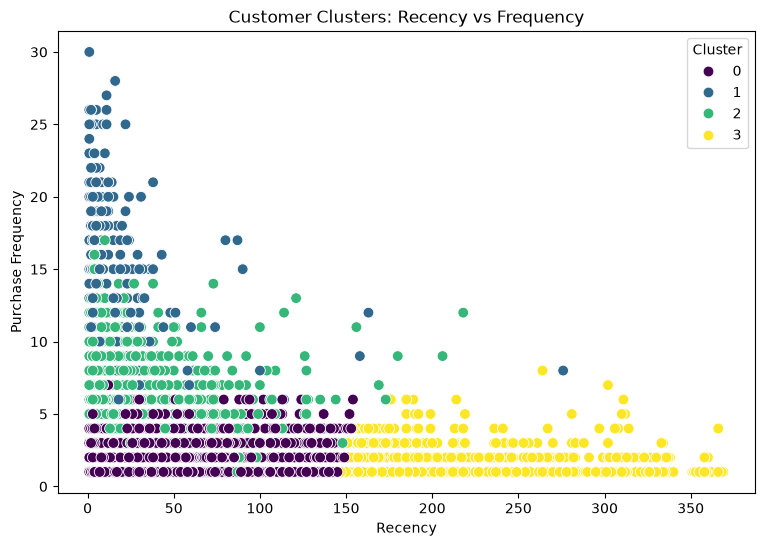

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm_clean,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Clusters: Recency vs Frequency")
plt.xlabel("Recency")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")

plt.show()

# STEP 15: VISUALISE CLUSTERS - FREQUENCY VS MONETARY

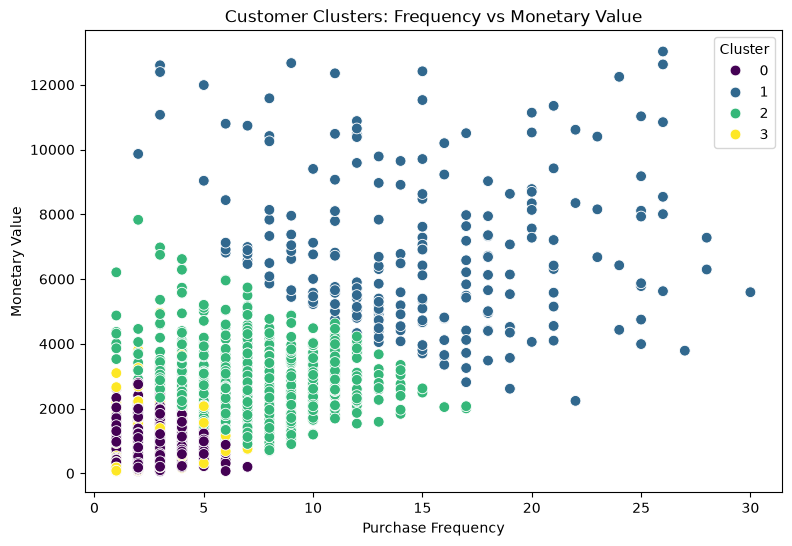

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm_clean,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Clusters: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

# STEP 16: NUMBER OF CUSTOMERS PER CLUSTER


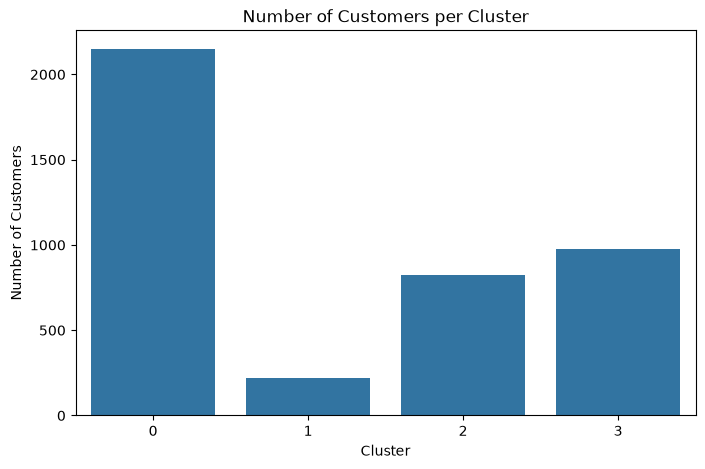

In [16]:
cluster_counts = (
    rfm_clean["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

# STEP 17: CUSTOMER TYPES AND MARKETING INSIGHTS

In [17]:
customer_types = {
    0: "At-Risk / Low-Value Customers",
    1: "Occasional / Low-Value Customers",
    2: "High-Value Loyal Customers",
    3: "Regular / Potential High-Value Customers"
}

marketing_actions = {
    0: "Use win-back campaigns, special discounts and reminders to encourage customers to return.",
    1: "Use personalised promotions, product recommendations and repeat-purchase offers.",
    2: "Provide VIP rewards, loyalty benefits, exclusive offers and premium products.",
    3: "Use cross-selling, loyalty programmes and targeted offers to increase purchase frequency and spending."
}

print("CUSTOMER SEGMENTS AND MARKETING RECOMMENDATIONS")
print("=" * 60)

for cluster in sorted(customer_types.keys()):
    print("\nCluster", cluster)
    print("Customer Type:", customer_types[cluster])
    print("Marketing Action:", marketing_actions[cluster])



CUSTOMER SEGMENTS AND MARKETING RECOMMENDATIONS

Cluster 0
Customer Type: At-Risk / Low-Value Customers
Marketing Action: Use win-back campaigns, special discounts and reminders to encourage customers to return.

Cluster 1
Customer Type: Occasional / Low-Value Customers
Marketing Action: Use personalised promotions, product recommendations and repeat-purchase offers.

Cluster 2
Customer Type: High-Value Loyal Customers
Marketing Action: Provide VIP rewards, loyalty benefits, exclusive offers and premium products.

Cluster 3
Customer Type: Regular / Potential High-Value Customers
Marketing Action: Use cross-selling, loyalty programmes and targeted offers to increase purchase frequency and spending.


The customer segmentation analysis successfully identifies different customer groups using RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering. The dataset was cleaned and prepared by removing missing values, duplicates, cancelled transactions, and invalid records. The RFM variables were then standardised, and the Elbow Method was used to select 4 customer clusters.

The resulting segments represent At-Risk / Low-Value Customers, Occasional / Low-Value Customers, High-Value Loyal Customers, and Regular / Potential High-Value Customers. Each segment can be targeted with suitable marketing strategies such as win-back campaigns, personalised promotions, VIP rewards, loyalty programmes, and cross-selling. Overall, the analysis demonstrates how customer segmentation can help businesses understand purchasing behaviour and develop more effective, targeted marketing strategies.